# Automating Protege Example

This notebook is an example of how to run Protege automatically, instead of interactively. This is useful when you already have catalogued anomalies and you want to check the performance. It uses the MGCLS example from https://arxiv.org/abs/2411.04188. Check the paper for links to the catalogue and data used here. Note that the original MGCLS fits files need to have their dimensionality collapsed before loading. I recommend doing this once and saving to disk.

## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

from astronomaly.preprocessing import image_preprocessing
from astronomaly.data_management import image_reader
from astronomaly.feature_extraction import byol_features
from astronomaly.dimensionality_reduction import pca
from astronomaly.anomaly_detection import protege, human_loop_learning
 
 # Nice interactive package can be installed with pip install ipympl
%matplotlib widget

## Setup

In [13]:
# ── Paths ──────────────────────────────────────────────────────────────────
root_dir = '/home/michelle/BigData/Anomaly/Meerkat_data/MGCLS_enhanced/'
image_dir = root_dir + 'Farcsec_collapsed'
catalogue_file = root_dir + 'Catalogues/protege_catalogue.csv'
output_dir = root_dir + 'astronomaly_output/'
force_rerun = False

# ── Transform switch ────────────────────────────────────────────────────────
# Options: 'sigma_clipped' | 'inverse_sinh'
transform_type = 'sigma_clipped'

if transform_type == 'sigma_clipped':
    image_transform_function = [
        image_preprocessing.image_transform_sigma_clipping,
        image_preprocessing.image_transform_remove_negatives,
        image_preprocessing.image_transform_scale,
    ]
elif transform_type == 'inverse_sinh':
    image_transform_function = [
        image_preprocessing.image_transform_inverse_sinh,
        image_preprocessing.image_transform_scale,
    ]

display_transform_function = image_transform_function


## Read the data

In [14]:
os.makedirs(output_dir, exist_ok=True)
catalogue = pd.read_csv(catalogue_file)
catalogue = catalogue.rename(columns={'obj_size_pixels': 'obj_size'})

image_dataset_full = image_reader.ImageDataset(
    directory=image_dir,
    window_size=128,
    output_dir=output_dir,
    plot_square=False,
    transform_function=image_transform_function,
    display_transform_function=display_transform_function,
    display_interpolation=None,
    adaptive_sizing=True,
    min_window_size=0,
    suppress_printing=True,
    catalogue=catalogue,
)

/home/michelle/Project/Anomaly/astronomaly/astronomaly/scripts/astronomaly_output/transform_sigma_clipped/astronomaly.log
Now switching to new log file:
/home/michelle/BigData/Anomaly/Meerkat_data/MGCLS_enhanced/astronomaly_output/astronomaly.log
A catalogue of  6161 sources has been provided.


## Extract BYOL features

In [18]:
features_file = output_dir + 'BYOL_Features.parquet'

if force_rerun or not os.path.exists(features_file):
    byol_pipeline = byol_features.BYOL_Features(
        output_dir=output_dir,
        n_epochs=100,
        batch_size=32,
        num_workers=16,
        force_rerun=force_rerun,
    )
    byol_pipeline.train_byol(image_dataset_full)
    features = byol_pipeline.run_on_dataset(image_dataset_full)
    features.to_parquet(features_file)
else:
    features = pd.read_parquet(features_file)
    print('Loaded features from', features_file)

print('Features shape:', features.shape)

Loaded features from /home/michelle/BigData/Anomaly/Meerkat_data/MGCLS_enhanced/astronomaly_output/BYOL_Features.parquet
Features shape: (6332, 1280)


## PCA reduction and evaluation set

In [19]:
pipeline_pca = pca.PCA_Decomposer(
    force_rerun=force_rerun,
    output_dir=output_dir,
    threshold=0.95,
)
features_pca = pipeline_pca.run(features)
print('Features shape:', features_pca.shape)

catalogue_evaluation = catalogue[catalogue['evaluation_subset_author_ML_score'] != -1].copy()
catalogue_evaluation.index = catalogue_evaluation['objid']
features_eval = features_pca.loc[features_pca.index.isin(catalogue_evaluation.index)]

labels = catalogue_evaluation[['evaluation_subset_author_ML_score']].rename(
    columns={'evaluation_subset_author_ML_score': 'human_label'})
labels['binary_label'] = ((labels['human_label'] == 4) | (labels['human_label'] == 5)).astype(int)

Running PCA_Decomposer ...
Total explained variance: 0.9506634
Done! Time taken: 1.9064362049102783 s
Features shape: (6332, 52)


## Run Protege

In [20]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, ei_tradeoff=0.5):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=ei_tradeoff)

    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:initial_steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition'] = active_output['acquisition']
    else:
        initial_steps = 0

    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = anomaly_scores[anomaly_scores.human_label == -1].index[:steps]
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition'] = active_output['acquisition']

    return anomaly_scores

In [21]:
initial_steps = 10

sorted_features = features_eval.sort_values(features_eval.columns[0])
selected_inds = np.linspace(0, len(sorted_features) - 1, initial_steps, dtype='int')
selected_inds = sorted_features.index[selected_inds]
anomaly_scores = pd.DataFrame(
    [0] * len(sorted_features),
    index=sorted_features.index,
    columns=['score'])
anomaly_scores.loc[selected_inds] = 1

pipeline_score_converter = human_loop_learning.ScoreConverter(
    force_rerun=True, output_dir=output_dir)
anomaly_scores = pipeline_score_converter.run(anomaly_scores)

active_output = run_GP_active_learning(
    features_eval,
    labels,
    anomaly_scores,
    output_dir,
    steps=10,
    initial_steps=10,
    N_labels=600,
    ei_tradeoff=0,
)

Running ScoreConverter ...
Running anomaly score rescaler...
Done! Time taken: 0.00691676139831543 s
Running GaussianProcess ...
Running GP regression with 10 training points


/home/michelle/venv/venv_astronomaly/lib64/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Done! Time taken: 0.07564902305603027 s
Running GaussianProcess ...
Running GP regression with 20 training points
Done! Time taken: 0.05474543571472168 s
Running GaussianProcess ...
Running GP regression with 30 training points
Done! Time taken: 0.051334381103515625 s
Running GaussianProcess ...
Running GP regression with 40 training points
Done! Time taken: 0.1448359489440918 s
Running GaussianProcess ...
Running GP regression with 50 training points
Done! Time taken: 0.07146239280700684 s
Running GaussianProcess ...
Running GP regression with 60 training points
Done! Time taken: 0.05260300636291504 s
Running GaussianProcess ...
Running GP regression with 70 training points
Done! Time taken: 0.13153314590454102 s
Running GaussianProcess ...
Running GP regression with 80 training points
Done! Time taken: 0.05344796180725098 s
Running GaussianProcess ...
Running GP regression with 90 training points
Done! Time taken: 0.05930471420288086 s
Running GaussianProcess ...
Running GP regressio

## Plot recall

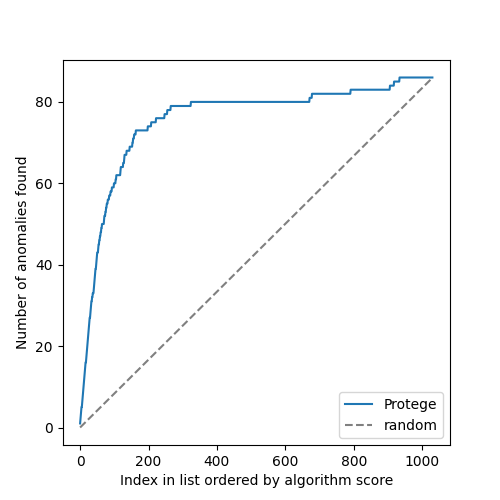

In [22]:
colours_dict = {'protege': 'C0'}
labels_dict = {'protege': 'Protege'}

sorted_inds = active_output.sort_values('trained_score', ascending=False).index
anom_inds = labels[labels['binary_label'] == 1].index
found_inds = sorted([np.where(sorted_inds == i)[0][0] for i in anom_inds])
recall = np.zeros(len(sorted_inds))
for i in found_inds:
    recall[i:] += 1

x = np.arange(len(recall))
random_recall = x * len(anom_inds) / len(sorted_inds)

plt.figure(figsize=(5, 5))
plt.plot(x, recall, color=colours_dict['protege'], label=labels_dict['protege'])
plt.plot(x, random_recall, color='grey', linestyle='dashed', label='random')
plt.legend()
plt.xlabel('Index in list ordered by algorithm score')
plt.ylabel('Number of anomalies found')
plt.show()